# Stratified sampling


Aim: compare sampling approaches in terms of spatial, temporal and species variation.

Method: 
1. Split data into strata i.e. per location (26 locations), species (106), temporal (this is the most challenging - it could show performance different between years 2020-2023 and between months)
2. Calculate baseline using BirdNet for each strata (The performance metric to beat)
3. Compare performance for batched active learning, cluster-based entropy, stratified-entropy

## Alternative Datasets
Avian Dawn Chorus: https://zenodo.org/records/8047850


In [66]:
# Same as wabad_finetuning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score
from pathlib import Path
from itertools import chain
import os
import random
import pickle
from tqdm import tqdm
from collections import defaultdict
from IPython.display import clear_output
from sampling import UncertaintyQuantification

# Ensure deterministic behavior for PyTorch operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

SAMPLE_RATE = 48000
dataset_path = "./WABAD"

BIRDNET_LABELS = Path(os.path.join(dataset_path,"data_files"), "BirdNET_GLOBAL_6K_V2.4_Labels.txt").read_text(encoding="utf-8").splitlines()
BIRDNET_LATIN_LABELS = [item.split('_')[0] for item in BIRDNET_LABELS]
BIRDNET_ENGLISH_LABELS = [item.split('_')[1] for item in BIRDNET_LABELS]

# Species that occure in at least one 1-minute files in both train and test sets (curruca cantillans removed)
bird_list = ['Acrocephalus arundinaceus', 'Acrocephalus scirpaceus', 'Alauda arvensis', 'Alectoris chukar', 'Anas platyrhynchos', 'Anthus pratensis', 'Anthus trivialis', 'Ardea cinerea', 'Athene noctua', 'Burhinus oedicnemus', 'Calandrella brachydactyla', 'Carduelis carduelis', 'Certhia brachydactyla', 'Cettia cetti', 'Chloris chloris', 'Chroicocephalus ridibundus', 'Circus aeruginosus', 'Cisticola juncidis', 'Coccothraustes coccothraustes', 'Columba oenas', 'Columba palumbus', 'Corvus corax', 'Corvus cornix', 'Corvus corone', 'Corvus monedula', 'Cuculus canorus', 'Curruca communis', 'Curruca conspicillata', 'Curruca iberiae', 'Curruca melanocephala', 'Curruca undata', 'Cyanistes caeruleus', 'Cyanopica cooki', 'Dendrocopos major', 'Dendrocoptes medius', 'Dryocopus martius', 'Emberiza calandra', 'Emberiza cia', 'Emberiza cirlus', 'Emberiza citrinella', 'Erithacus rubecula', 'Falco tinnunculus', 'Ficedula albicollis', 'Fringilla coelebs', 'Fringilla montifringilla', 'Fulica atra', 'Galerida cristata', 'Galerida theklae', 'Gallinula chloropus', 'Gallus gallus', 'Garrulus glandarius', 'Grus grus', 'Himantopus himantopus', 'Hippolais polyglotta', 'Lanius senator', 'Larus argentatus', 'Linaria cannabina', 'Locustella naevia', 'Lophophanes cristatus', 'Lullula arborea', 'Luscinia megarhynchos', 'Merops apiaster', 'Milvus migrans', 'Motacilla flava', 'Oriolus oriolus', 'Parus major', 'Passer domesticus', 'Periparus ater', 'Petronia petronia', 'Phasianus colchicus', 'Phoenicopterus roseus', 'Phoenicurus ochruros', 'Phylloscopus bonelli', 'Phylloscopus collybita', 'Phylloscopus sibilatrix', 'Phylloscopus trochilus', 'Pica pica', 'Picus sharpei', 'Poecile palustris', 'Prunella collaris', 'Prunella modularis', 'Pyrrhocorax pyrrhocorax', 'Pyrrhula pyrrhula', 'Rallus aquaticus', 'Recurvirostra avosetta', 'Regulus ignicapilla', 'Regulus regulus', 'Remiz pendulinus', 'Saxicola rubetra', 'Saxicola rubicola', 'Serinus serinus', 'Sitta europaea', 'Spinus spinus', 'Streptopelia decaocto', 'Sturnus unicolor', 'Sylvia atricapilla', 'Tachybaptus ruficollis', 'Tadorna ferruginea', 'Tadorna tadorna', 'Tringa glareola', 'Tringa ochropus', 'Troglodytes troglodytes', 'Turdus merula', 'Turdus philomelos', 'Turdus viscivorus', 'Upupa epops']
birds_list_index = []
for specie_name in bird_list:
    birds_list_index.append( BIRDNET_LATIN_LABELS.index(specie_name))
bird_list_english = (np.asarray(BIRDNET_ENGLISH_LABELS)[birds_list_index]).tolist()
labels_name = bird_list


cpu


In [67]:
# load train labels and sampling data
with open(os.path.join(dataset_path,"data_files" ,  "dataframe_train.pkl"), "rb") as file:
    loaded_data = pickle.load(file)

[samples_df_train, y_true_train, y_scores_train] = loaded_data

train_sets_size = y_true_train.shape[0]
y_true_train = y_true_train.astype(int)
y_true_train = y_true_train[:,birds_list_index]

birdnet_scores_train = y_scores_train[:,birds_list_index]


# load validation labels
with open(os.path.join(dataset_path,"data_files" , "dataframe_validation.pkl"), "rb") as file:
    loaded_data = pickle.load(file)
[samples_df_val, y_true_val, y_scores_val] = loaded_data

train_val_size = y_true_val.shape[0]
y_true_val = y_true_val.astype(int)
y_true_val = y_true_val[:,birds_list_index]

# load test embeddings
with open(os.path.join(dataset_path,"data_files" , "embeddings_train.pkl"), "rb") as file:
    loaded_data = pickle.load(file)
[embeddings_train, files_list] = loaded_data

verif = (samples_df_train["File"] == files_list).tolist()

# load validation embeddings
with open(os.path.join(dataset_path,"data_files" , "embeddings_validation.pkl"), "rb") as file:
    loaded_data = pickle.load(file)
[embeddings_val, files_list] = loaded_data

verif = (samples_df_val["File"] == files_list).tolist()

# Select species in the bird list
num_classes =  len(labels_name)

### DATA SAMPLING

In [68]:
## Train - validation split
x_train = embeddings_train
x_val = embeddings_val
y_train = y_true_train
y_val = y_true_val

# # Needs for resampling
full_train = x_train 
full_labels = y_train
print('Full training set', np.shape(full_train))


Full training set (13453, 1024)


Per cluster uncertainty sampling using binary entropy. Authors of cluster-margin use the margin score. As we are taking the top k confidence scores these approaches are similar.

In [69]:
tensor_full_train = torch.Tensor(full_train)
tensor_full_labels = torch.Tensor(full_labels)
tensor_x_train = torch.Tensor(x_train) # transform to torch tensor
tensor_y_train = torch.Tensor(y_train)
tensor_x_val = torch.Tensor(x_val) # transform to torch tensor
tensor_y_val = torch.Tensor(y_val)

val_dataset = TensorDataset(tensor_x_val,tensor_y_val) # create your datset

batch_size = 20
val_loader = DataLoader(val_dataset, batch_size=batch_size) # create your dataloader

print(tensor_x_train.shape)
print(tensor_y_train.shape)

torch.Size([13453, 1024])
torch.Size([13453, 106])


Model

In [70]:
#Load pretrained birdNET last layer
with open("./BirdNet/birdnet_last_layer.pkl", "rb") as file:
    loaded_data = pickle.load(file)

[birdnet_weights, birdnet_bias] = loaded_data
birdnet_weights = birdnet_weights[birds_list_index,:]
birdnet_bias = birdnet_bias[birds_list_index]

birdnet_weights = torch.tensor(birdnet_weights, dtype=torch.float32).to(device)
birdnet_bias = torch.tensor(birdnet_bias, dtype=torch.float32).to(device)


class ClassificationHead(nn.Module):
    def __init__(self, input_size, output_size, weight_matrix=None, bias_vector=None):
        super(ClassificationHead, self).__init__()
        self.fc = nn.Linear(input_size, output_size)
        
        if weight_matrix is not None:
            with torch.no_grad():  # Disable gradient tracking during initialization
                self.fc.weight = nn.Parameter(torch.tensor(weight_matrix, dtype=torch.float32))
        
        if bias_vector is not None:
            with torch.no_grad():  # Disable gradient tracking during initialization
                self.fc.bias = nn.Parameter(torch.tensor(bias_vector, dtype=torch.float32))

    def forward(self, x):
        x = self.fc(x)
        return x

    
input_dim = embeddings_train.shape[1]


Model hyperparameters

In [71]:
learning_rate = 0.001
num_epochs = 25
lambda_reg_weights = 0.0005
lambda_reg_biais = 0.0005
initialisation = False

if initialisation:
    model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=birdnet_weights.clone().detach(), bias_vector=birdnet_bias.clone().detach()).to(device)
else:
    model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=None, bias_vector=None).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Initialise training set sampler

# Evaluation Across Strata
Load test data

In [72]:
#load test labels
with open(os.path.join(dataset_path,"data_files" , "dataframe_test.pkl"), "rb") as file:
    loaded_data = pickle.load(file)

[samples_df_test, y_true_test, y_scores_test] = loaded_data

y_true_test = y_true_test[:,birds_list_index]
y_true_test = y_true_test.astype(int)

num_samples_test = np.shape(y_true_test)[0]
species_count_test = np.sum(y_true_test,axis=0)

#Load test embeddings
with open(os.path.join(dataset_path,"data_files" , "embeddings_test.pkl"), "rb") as file:
    loaded_data = pickle.load(file)

[embeddings_test, files_list_test] = loaded_data
verif = (samples_df_test["File"] == files_list_test).tolist()

embeddings_test = torch.tensor(embeddings_test)
y_true_test = torch.tensor(y_true_test)

Compute the model confidence and entropy for the test set

In [73]:
def binaryEntropy(outputs: torch.Tensor, eps=1e-8) -> torch.Tensor:
    entropy = -(outputs * torch.log2(outputs + eps) + (1 - outputs) * torch.log2(1 - outputs + eps))  # (B, C)
    entropy = torch.nan_to_num(entropy)
    return entropy

def predictions(embeddings: torch.Tensor, labels: torch.Tensor, model=None):
    model.eval()
    with torch.no_grad():
        outputs = model(embeddings)
        y_pred = torch.sigmoid(outputs)
    uncertainty = binaryEntropy(y_pred)
    return y_pred, labels, uncertainty


## Per location evaluation

In [74]:
def stratified_evaluation(stratified_indices: dict, y_pred: torch.Tensor, y_true: torch.Tensor, uncertainty: torch.Tensor, indices_selected:dict=None, init_mAP=None, init_mAE=None, plot=False):
    """
    Evaluate model performance (mAP) and uncertainty (binary entropy) per species and strata
    Parameters:
        stratified_indices: dict of list of indices for each strata
    """
    strata_mAP = []
    strata_mAE = []

    # mAP = average_precision_score(y_true_strata, y_pred_strata, average='weighted')

    # Evaluate mAP per location
    for loc, indices in stratified_indices.items():
        y_true_strata = y_true[indices]
        y_pred_strata = y_pred[indices]

        valid_classes = y_true_strata.sum(axis=0) > 0

        y_true_strata = y_true_strata[:, valid_classes]
        y_pred_strata = y_pred_strata[:, valid_classes]

        # Compute entropy per class and location
        valid_entropy = uncertainty[indices][:, valid_classes]
        per_class_entropy = valid_entropy.mean(axis=0)
        mAE = per_class_entropy.mean()

        mAP = average_precision_score(y_true_strata, y_pred_strata, average='weighted')

        strata_mAP.append(mAP)
        strata_mAE.append(mAE.item())

    if plot:
        strata = list(stratified_indices.keys())
        fig, ax = plt.subplots(1, 2, figsize=(6 , 6), gridspec_kw={'width_ratios': [3, 2]})

        if init_mAP is not None:
            strata_mAP = np.subtract(strata_mAP, init_mAP).tolist()
            ax[0].set_xlabel('Relative Mean Average Precision (mAP)')
        else:
            ax[0].set_xlabel('Mean Average Precision (mAP)')

        ax[0].barh(strata[::-1], strata_mAP[::-1])
        ax[0].barh(strata[::-1], strata_mAE[::-1], alpha=0.5)

    
        if indices_selected is not None:
            selected = []
            indices_selected = {k: indices_selected[k] for k in stratified_indices} # Aligns train/test dicts due to differring samples counts
            keys = list(indices_selected.keys())
            for strata_indices in indices_selected.values():
                selected.append(len(strata_indices))
            ax[1].barh(keys[::-1], selected[::-1])
            ax[1].set_xlabel('Number of Samples selected') 
        else:
            keys = list(stratified_indices.keys())
            counts = [len(v) for v in stratified_indices.values()]
            ax[1].barh(keys[::-1], counts[::-1])
            ax[1].set_xlabel('Total Samples') 
        
        ax[0].set_ylabel(f'Strata')
        ax[0].set_xlim(-0.5,1)
        plt.grid(True, axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return strata_mAP, strata_mAE


def temporal_split(files):
    year_code = [loc.split('_')[1][:4] for loc in files]
    value_to_indices = defaultdict(list)

    for idx, val in enumerate(year_code):
        value_to_indices[val].append(idx)
    value_to_indices = dict(value_to_indices)

    sorted_dict = dict(sorted(value_to_indices.items(), key=lambda x: int(x[0])))
    sorted_time_to_indices = dict(sorted_dict)
    return sorted_time_to_indices


def spatial_split(files):
    # Collect indices per location
    location_codes = [loc.split('_')[0] for loc in files]
    value_to_indices = defaultdict(list)

    for idx, val in enumerate(location_codes):
        value_to_indices[val].append(idx)
    value_to_indices = dict(value_to_indices)

    sorted_locs = sorted(value_to_indices.items(), key=lambda item: len(item[1]), reverse=True)
    sorted_location_to_indices = dict(sorted_locs)
    return sorted_location_to_indices


# # Usage example # #
# mode = "spatial"
# print(f"-- {mode} split --")

# model.load_state_dict(torch.load("uncertainty_BirdNet.pt", weights_only=True))
# y_pred, y_true, uncertainty = predictions(embeddings_test, y_true_test, model=model)

# if mode == "spatial":
#     sorted_indices = spatial_split(files_list_test)
# if mode == "temporal":
#     sorted_indices = temporal_split(files_list_test)

# strata_mAP, strata_mAE = stratified_evaluation(sorted_indices, y_pred, y_true, uncertainty, plot=True)


# Evaluation Across Strata
Load test data

In [75]:
from scipy.spatial.distance import jensenshannon
import seaborn as sns


def correlation(sorted_indices, probabilities=None, uncertainty=None, mode='prob'):                     
    if mode == 'prob':
        sorted_scores = {key: probabilities[idx] for key, idx in sorted_indices.items()}
    if mode == 'entropy':
        sorted_scores = {key: uncertainty[idx] for key, idx in sorted_indices.items()}

    def js_divergence(pA, pB):
        return jensenshannon(pA.mean(axis=0), pB.mean(axis=0)) ** 2

    location_names = list(sorted_scores.keys())
    n = len(location_names)
    js_matrix = np.zeros((n, n))

    for i in range(n):
        loc1 = location_names[i]
        for j in range(n):
            loc2 = location_names[j]
            js_matrix[i,j] = js_divergence(sorted_scores[loc1], sorted_scores[loc2])

    sns.clustermap(js_matrix, 
                row_cluster=False, col_cluster=False, 
                figsize=(12, 10), 
                xticklabels=location_names, yticklabels=location_names, 
                cmap="magma", linewidths=0.5)
    plt.suptitle("Clustered JS Divergence Between Locations", y=1.02)
    plt.show()



In [76]:
# --- Model Hyperparameters ---
learning_rate = 0.01
num_epochs = 25
max_samples = 2000
lambda_reg_weights = 0.0005
lambda_reg_biais = 0.0005
initialisation = True
# ---

if initialisation:
    model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=birdnet_weights.clone().detach(), bias_vector=birdnet_bias.clone().detach()).to(device)
else:
    model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=None, bias_vector=None).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=1, min_lr=0.001)


C:\Users\bjmcewen\AppData\Local\Temp\ipykernel_15344\1132731939.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.fc.weight = nn.Parameter(torch.tensor(weight_matrix, dtype=torch.float32))
C:\Users\bjmcewen\AppData\Local\Temp\ipykernel_15344\1132731939.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.fc.bias = nn.Parameter(torch.tensor(bias_vector, dtype=torch.float32))


In [77]:
# --- Active Learning Hyperparameters --- 
n_samples = 50
accumulation = True

initial_sampling_mode = "random"
sampling_mode = "binary"
sub_sampling_mode = "binary"
strata_mode = "spatial"

posthoc_sampling = False
posthoc_target = 20
# ---

embeddings_train = torch.Tensor(embeddings_train)
y_train = torch.Tensor(y_train)
y_pred, y_true, uncertainty = predictions(embeddings_train, y_train, model=model)

# Given a list of filenames corresponding to each indice, sort by location
training_list = list(samples_df_train["File"])

if strata_mode == "spatial":
    sorted_indices_train = spatial_split(training_list)
elif strata_mode == "temporal":
    sorted_indices_train = temporal_split(training_list)

strata_mAP, strata_mAE = stratified_evaluation(sorted_indices_train, y_pred, y_true, uncertainty, plot=False)

# Stratafied sampling
sampling = UncertaintyQuantification(tensor_full_train, tensor_full_labels, n_samples)

if initial_sampling_mode == "stratified":
    embeddings, labels, strata_idx = sampling.stratified(model, sorted_indices_train, method=sub_sampling_mode)

    # location = "HAG"
    # idx = strata_idx[location]
    # embeddings = tensor_full_train[idx]
    # labels = tensor_full_labels[idx]

    # strata_idx = {k: [] for k in strata_idx}
    # strata_idx[location] = idx
else:
    embeddings, labels, idx = sampling.resample(model, method=initial_sampling_mode) # initial sampling fixed at 20 samples

train_dataset = TensorDataset(embeddings, labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

y_pred_test, y_true_test, uncertainty, = predictions(embeddings_test, y_true_test, model=model) # Recompute predictions/uncertanty using updated model

if strata_mode == "spatial":
    sorted_indices = spatial_split(files_list_test)
elif strata_mode == "temporal":
    sorted_indices = temporal_split(files_list_test)
    
strata_mAP, strata_mAE = stratified_evaluation(sorted_indices, y_pred_test, y_true_test, uncertainty, indices_selected=None, plot=False)
initial_results = {"strata": list(sorted_indices_train.keys()),
                   "mAP": strata_mAP,
                   "mAE": strata_mAE}

initial_results_df = pd.DataFrame(initial_results)


Epoch 25: Val Loss: 0.0355, mAP: 0.6290, cmAP: 0.4648, F1 Score: 0.5356
[0.001]
Total positive samples: 1153/1250, percentage: 92.2%


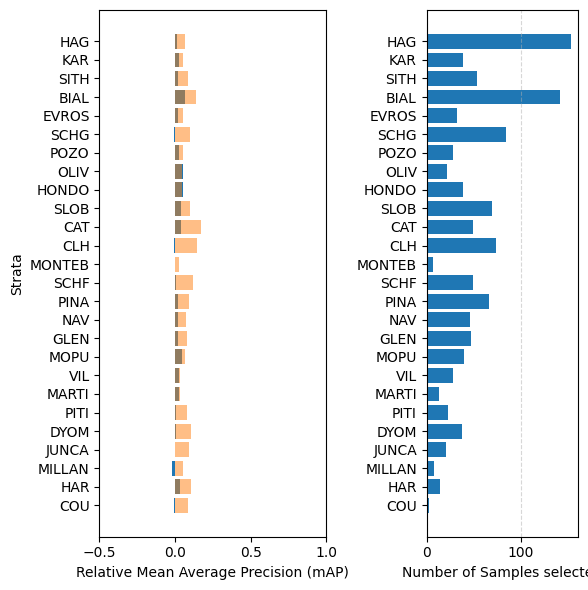

In [78]:

train_losses = [] 
val_losses = [] 
val_mAP = []
val_cmAP = []
val_F1 = []

indices = [] # idx_train_selection.tolist() # Used to see how many unique samples have been sampled
all_selected = indices.copy()
strata_selected = {}

for epoch in tqdm(range(num_epochs), disable=True):

    for i, (inputs, labels) in enumerate(train_loader):
        model.train()
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        if initialisation:
            total_loss = loss + lambda_reg_weights*torch.norm(model.fc.weight - birdnet_weights,2) + lambda_reg_biais*torch.norm(model.fc.bias - birdnet_bias,2) 
        else:
            total_loss = loss

        # Backward pass and optimization
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Validation phase
        model.eval()
        epoch_probs= []
        epoch_labels = []
        epoch_max = []
        val_loss = 0.0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Thresholding
                threshold = 0.5
                probs = torch.sigmoid(outputs)
                preds = (probs > threshold).float()

                epoch_probs.append(probs.cpu().numpy())
                epoch_labels.append(labels.cpu().numpy())
                epoch_max.append(preds.cpu().numpy()) 

        epoch_val_loss = val_loss / len(val_loader)
        
        mAP = average_precision_score(np.concatenate(epoch_labels),np.concatenate(epoch_probs) , average="weighted", sample_weight=None)
        cmAP = average_precision_score(np.concatenate(epoch_labels),np.concatenate(epoch_probs) , average="macro", sample_weight=None)
        F1_score = f1_score(np.concatenate(epoch_labels), np.concatenate(epoch_max), average="weighted")
        
        # train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_mAP.append(mAP)
        val_cmAP.append(cmAP)
        val_F1.append(F1_score)

    print(f"Epoch {epoch+1}: Val Loss: {epoch_val_loss:.4f}, mAP: {mAP:.4f}, cmAP: {cmAP:.4f}, F1 Score: {F1_score:.4f}")
    scheduler.step(mAP)
    print(scheduler.get_last_lr())
    
    # Resampling
    if sampling_mode == "stratified":
        embeddings, labels, strata_idx = sampling.stratified(model, sorted_indices_train, method=sub_sampling_mode, indices=all_selected)

        # # Filter by strata
        # strata = "2023"
        # idx = strata_idx[strata]
        # embeddings = tensor_full_train[idx]
        # labels = tensor_full_labels[idx]

        # strata_idx = {k: [] for k in strata_idx}
        # strata_idx[strata] = idx

        idx = list(chain.from_iterable(strata_idx.values()))
        if posthoc_sampling and (len(idx) > posthoc_target):
            idx = np.random.choice(idx, size=posthoc_target, replace=False)
    else:
        embeddings, labels, idx = sampling.resample(model, method=sampling_mode, indices=all_selected)

    if accumulation:
        indices += list(idx)
    else:
        indices = idx
    all_selected += list(idx)

    for key, value in sorted_indices_train.items():
        strata_selected[key] = np.intersect1d(value, all_selected)
    strata_idx = strata_selected

    training_set = tensor_full_train[indices,:]
    label_set = tensor_full_labels[indices,:]

    # Positive samples selected
    positive_samples = label_set.sum(axis=1) > 0
    positive_samples = positive_samples.sum()
    total = label_set.shape[0]
    print(f"Total positive samples: {positive_samples}/{total}, percentage: {100*(positive_samples/total):.1f}%")

    train_dataset = TensorDataset(training_set, label_set) # create datset
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # create dataloader
    

    # --- Evaluate on test set across strata ---
    y_pred_test, y_true_test, uncertainty, = predictions(embeddings_test, y_true_test, model=model) # Recompute predictions/uncertanty using updated model
    if strata_mode == "spatial":
        sorted_indices = spatial_split(files_list_test)
    elif strata_mode == "temporal":
        sorted_indices = temporal_split(files_list_test)

    strata_mAP, strata_mAE = stratified_evaluation(sorted_indices, y_pred_test, y_true_test, uncertainty, indices_selected=strata_idx, init_mAP=initial_results["mAP"], plot=True)

    clear_output(wait=True)

    if len(all_selected) > max_samples:
        break

# With BirdNet initialisation and initial selection using random sampling
# Stratified (Binary max)
# mAP: 0.6405, cmAP: 0.4704, F1 Score: 0.5523 (25 epochs)
# mAP: 0.6354, cmAP: 0.4791, F1 Score: 0.4575 (10 epochs)

# Stratified (random)
# mAP: 0.6366, cmAP: 0.4618, F1 Score: 0.4594 (25 epochs)
# mAP: 0.6343, cmAP: 0.4720, F1 Score: 0.4605 (10 epochs)

# Stratified (ratio max)
# mAP: 0.6294, cmAP: 0.4633, F1 Score: 0.4699 (25 epochs)
# mAP: 0.6226, cmAP: 0.4449, F1 Score: 0.4895 (10 epochs)

# Random
# mAP: 0.6186, cmAP: 0.4509, F1 Score: 0.5046 (25 epochs)
# mAP: 0.5990, cmAP: 0.4355, F1 Score: 0.4528 (10 epochs)


# # 50 samples, accumulation
# Random
# Epoch 25: Val Loss: 0.0336, mAP: 0.6324, cmAP: 0.4691, F1 Score: 0.5361

In [79]:
epochs_range = range(1, len(val_mAP)+1)
# np.save('entropy_mAP_20s.npy', val_mAP)
random_mAP = np.load('random_mAP_20s.npy')
entropy_mAP = np.load('entropy_mAP_20s.npy')

plt.plot(epochs_range, random_mAP)
plt.plot(epochs_range, entropy_mAP)
plt.plot(epochs_range, val_mAP)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'random_mAP_20s.npy'

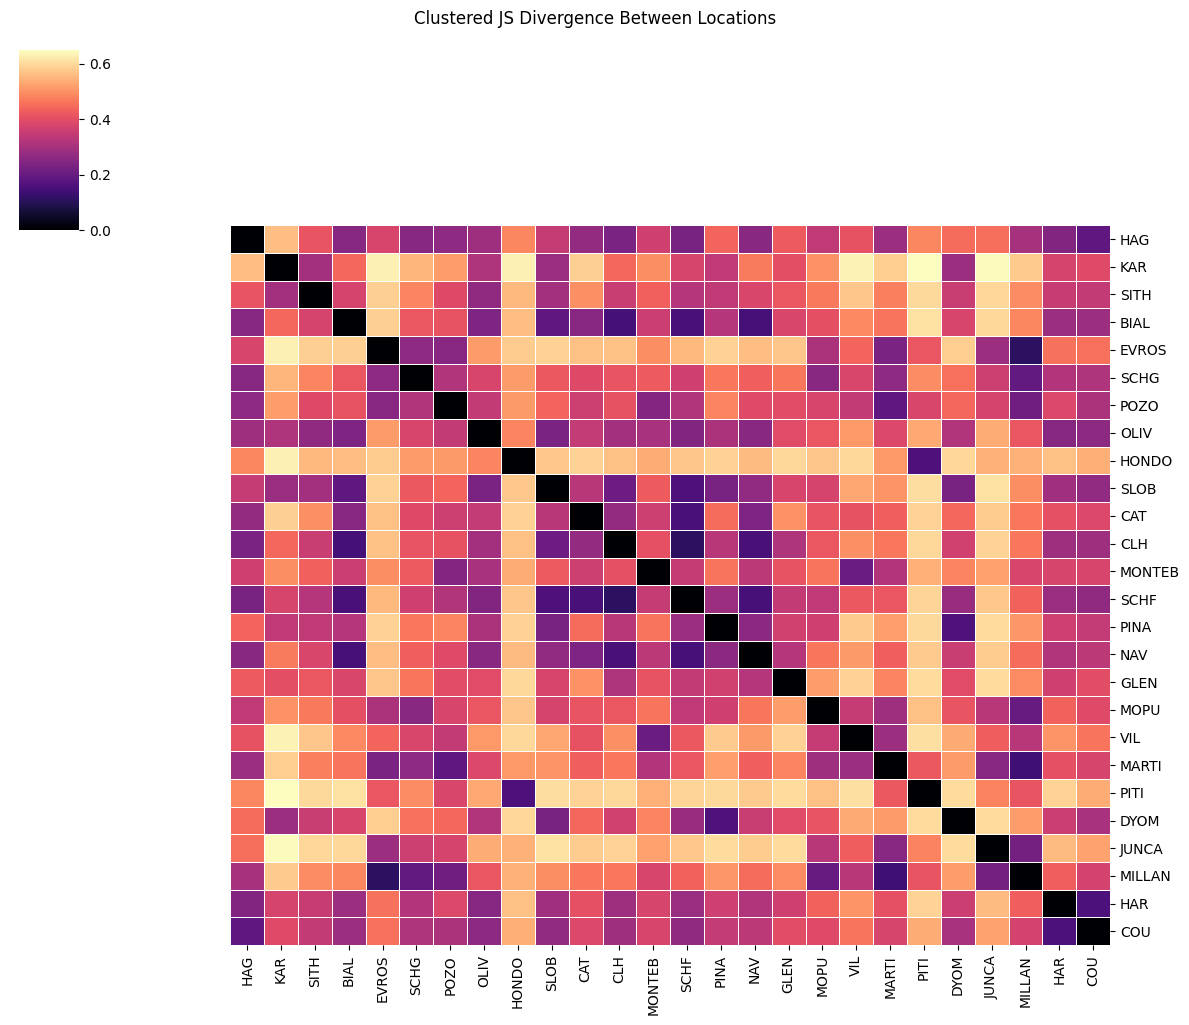

In [ ]:

correlation(sorted_indices, probabilities=y_pred_test)

In [ ]:
print(strata_mAP)

[0.006745487969179398, 0.01164994232415062, -0.00022655300899487862, 0.04016305415332466, 0.009962834883245675, 0.0008132932656734759, 0.027054400934948097, 0.006047332891441548, 0.0614508717484068, 0.02260747330074875, 0.05436780007099451, 0.019170680485800617, -0.022915557774608297, -0.013546555707819263, -0.026026201020031725, -0.0031995406995710685, 0.010359288333149808, 0.04116959726426783, 0.008937099689469208, 0.012498143871059908, 0.047175862062815654, 0.009155762994162098, -0.021280141734236868, 0.007033201214444729, 0.023622370037642337, -0.016701266048281704]


In [ ]:
# # Confidence Initisation
# Random
# mAP: 0.5087, cmAP: 0.2312, F1 Score: 0.3380
# mAP: 0.5024, cmAP: 0.2250, F1 Score: 0.3279
# mAP: 0.5151, cmAP: 0.2257, F1 Score: 0.2657

# Ratio max
# mAP: 0.4920, cmAP: 0.1867, F1 Score: 0.3361
# mAP: 0.5078, cmAP: 0.2029, F1 Score: 0.3857
# mAP: 0.4633, cmAP: 0.1799, F1 Score: 0.3076

# # Random Initialisation
# Random
# mAP: 0.5265, cmAP: 0.2327, F1 Score: 0.3278
# mAP: 0.5228, cmAP: 0.2296, F1 Score: 0.3425
# mAP: 0.5532, cmAP: 0.2544, F1 Score: 0.3599

# Ratio max
# mAP: 0.5297, cmAP: 0.2354, F1 Score: 0.3359
# mAP: 0.5190, cmAP: 0.2177, F1 Score: 0.3277
# mAP: 0.5148, cmAP: 0.2037, F1 Score: 0.3667

# With BirdNet initialisation and initial selection using random sampling
# Stratified (random)
# mAP: 0.6366, cmAP: 0.4618, F1 Score: 0.4594 (25 epochs)
# mAP: 0.6343, cmAP: 0.4720, F1 Score: 0.4605 (10 epochs)

# Stratified (ratio max)
# mAP: 0.6294, cmAP: 0.4633, F1 Score: 0.4699 (25 epochs)
# mAP: 0.6226, cmAP: 0.4449, F1 Score: 0.4895 (10 epochs)

# Random
# mAP: 0.6186, cmAP: 0.4509, F1 Score: 0.5046 (25 epochs)
# mAP: 0.5990, cmAP: 0.4355, F1 Score: 0.4528 (10 epochs)



# Temporal - Stratified Random
# Epoch 25: Val Loss: 0.0494, mAP: 0.5497, cmAP: 0.4192, F1 Score: 0.3646
# Epoch 10: Val Loss: 0.0533, mAP: 0.5447, cmAP: 0.4214, F1 Score: 0.3564

# Temporal - Stratified Ratio max
# Epoch 25: Val Loss: 0.0489, mAP: 0.5426, cmAP: 0.4049, F1 Score: 0.3381
# Epoch 10: Val Loss: 0.0515, mAP: 0.5378, cmAP: 0.4066, F1 Score: 0.3298

# Random
# Epoch 25: Val Loss: 0.0518, mAP: 0.5349, cmAP: 0.4114, F1 Score: 0.3574
# Epoch 10: Val Loss: 0.0550, mAP: 0.5315, cmAP: 0.4097, F1 Score: 0.3364


# Aggregation comparison (stratified)
# Binary (max) Epoch 10: Val Loss: 0.0466, mAP: 0.5787, cmAP: 0.4236, F1 Score: 0.4071
# Ratio (max) Epoch 10: Val Loss: 0.0497, mAP: 0.5641, cmAP: 0.4186, F1 Score: 0.3908
# Binary (mean) Epoch 10: Val Loss: 0.0545, mAP: 0.5547, cmAP: 0.4029, F1 Score: 0.3292

# Binary (max)
# Epoch 25: Val Loss: 0.0364, mAP: 0.6405, cmAP: 0.4704, F1 Score: 0.5523
# Epoch 10: Val Loss: 0.0450, mAP: 0.6354, cmAP: 0.4791, F1 Score: 0.4575
